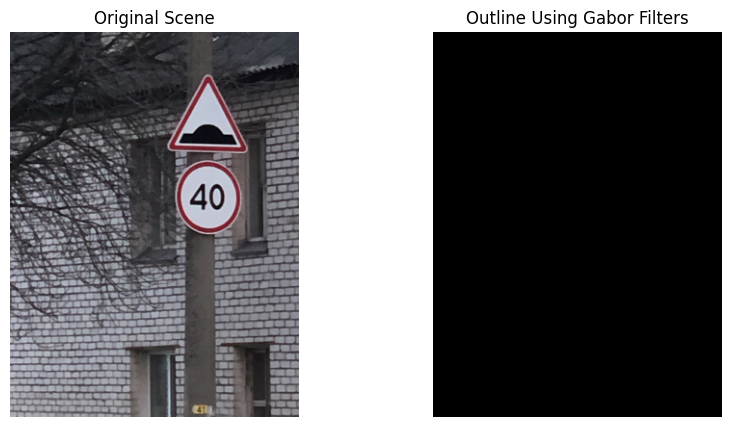

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def gabor_filter_bank(k_size=5, num_filters=8):
    """Create a bank of Gabor filters."""
    filters = []
    for theta in np.linspace(0, np.pi, num_filters, endpoint=False):  # Different orientations
        for sigma in [1.0, 2.0]:  # Different scales
            kernel = cv2.getGaborKernel((k_size, k_size), sigma, theta, 10, 0.5, 0, ktype=cv2.CV_32F)
            filters.append(kernel)
    return filters

def apply_gabor_filters(image, filters):
    """Apply each Gabor filter to the image and return the combined results."""
    filtered_images = []
    for kernel in filters:
        # Apply the filter (convolution) to the image
        filtered_image = cv2.filter2D(image, cv2.CV_8UC3, kernel)
        filtered_images.append(filtered_image)
    
    # Combine filtered images by taking the absolute value of the sum of all filtered images
    combined = np.zeros_like(image, dtype=np.float32)
    for filtered_image in filtered_images:
        combined += np.abs(filtered_image)
    
    # Normalize the result for better visualization
    combined = np.uint8(np.clip(combined, 0, 255))
    return combined

def outline_using_gabor(image):
    """Use Gabor filters to extract an outline of a sign in the image."""
    # Convert the image to grayscale
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Create a bank of Gabor filters
    filters = gabor_filter_bank(k_size=7, num_filters=8)

    # Apply Gabor filters to the grayscale image
    filtered_image = apply_gabor_filters(gray_image, filters)

    # Apply threshold to get a binary outline
    _, thresholded_image = cv2.threshold(filtered_image, 127, 255, cv2.THRESH_BINARY)

    return thresholded_image

# Load your scene image
scene_image = cv2.imread("./Task-1/img3.png")

# Get the outline of the sign in the scene using Gabor filters
outline_image = outline_using_gabor(scene_image)

# Display the results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(scene_image, cv2.COLOR_BGR2RGB))
plt.title("Original Scene")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(outline_image, cmap='gray')
plt.title("Outline Using Gabor Filters")
plt.axis('off')

plt.show()
